         date  down_hole_presure  down_hole_temperature  \
0  13/07/2008            260.867                103.293   
1  14/07/2008            256.248                104.018   
2  15/07/2008            254.983                103.967   
3  16/07/2008            251.476                104.211   
4  17/07/2008            249.346                104.339   

   production_pipe_pressure  choke_size_pct  well_head_presure  \
0                   160.152          21.053            100.715   
1                   156.650          27.223             99.598   
2                   156.333          27.278             98.650   
3                   155.817          30.651             95.659   
4                   155.761          32.563             93.585   

   well_head_temperature  choke_size_pressure      oil  
0                 52.382               69.539  1735.26  
1                 71.115               68.016   592.36  
2                 67.591               66.949  2532.21  
3                 73

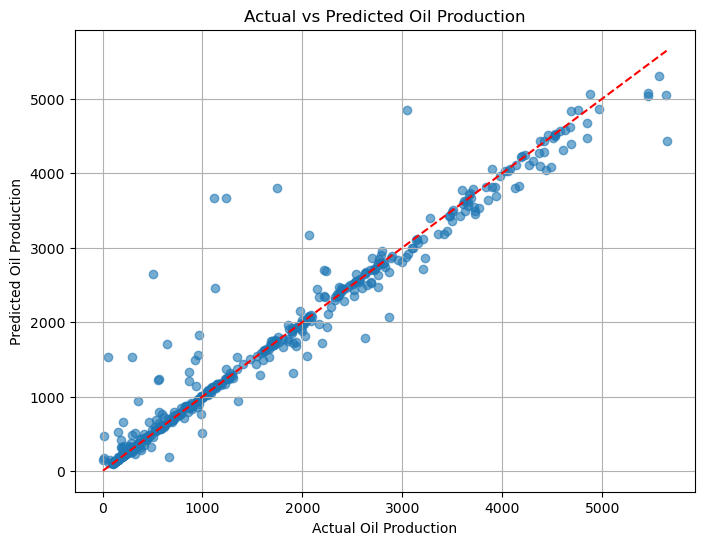

In [17]:
#RANDOM FOREST
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("volve_field_data.csv")

print(df.head())
df.dropna(inplace=True)


df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Extract useful date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

# Remove original date column
df.drop("date", axis=1, inplace=True)

X = df.drop("oil", axis=1)
y = df["oil"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("=" * 40)
print("Model Performance")
print("=" * 40)

print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Oil Production")
plt.ylabel("Predicted Oil Production")
plt.title("Actual vs Predicted Oil Production")
plt.grid(True)
plt.show()



In [15]:
LINEAR REGREESION

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



df = pd.read_csv("volve_field_data.csv")


df.dropna(inplace=True)

# -----------------------------
# Convert Date Column
# -----------------------------
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Extract date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

# Remove original date column
df.drop("date", axis=1, inplace=True)



X = df.drop("oil", axis=1)
y = df["oil"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = LinearRegression()

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

# -----------------------------
# Evaluate
# -----------------------------
print("=" * 40)
print("Linear Regression Performance")
print("=" * 40)

print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE       : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE      : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² Score  : {r2_score(y_test, y_pred):.4f}")

# -----------------------------
# Coefficients
# -----------------------------
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients")
print(coefficients)




Linear Regression Performance
MAE       : 402.1646
MSE       : 378110.1457
RMSE      : 614.9066
R² Score  : 0.7864

Feature Coefficients
                    Feature  Coefficient
0         down_hole_presure    -3.668638
1     down_hole_temperature    10.805380
2  production_pipe_pressure    -0.684619
3            choke_size_pct    -0.298909
4         well_head_presure     3.634349
5     well_head_temperature    14.671034
6       choke_size_pressure     4.230467
7                      year  -412.382476
8                     month   -23.332940
9                       day     1.639575

Model saved as 'linear_regression_oil_model.pkl'
